In [1]:
import numpy as np
import pandas as pd

In [3]:
data = pd.read_csv("SMSSpamCollection", sep='\t', names=["label", "msg"])

In [4]:
data

,label,msg
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   msg     5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
data.isnull().sum()

label    0
msg      0
dtype: int64

In [7]:
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

In [8]:
data

,label,msg
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will ü b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='label', ylabel='count'>

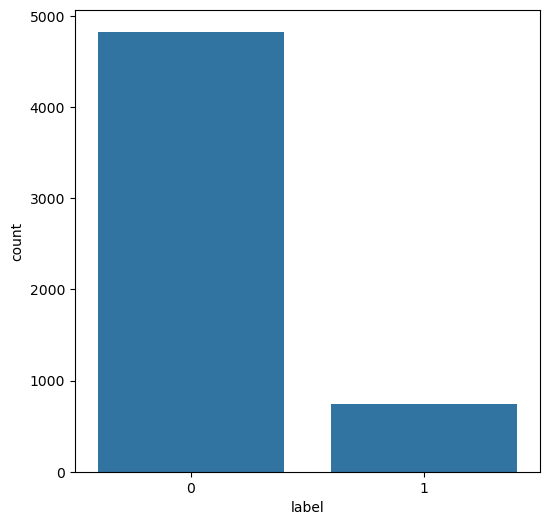

In [10]:
plt.figure(figsize=(6,6))
sns.countplot(x="label",data=data)

In [12]:
only_spam = data[data['label'] == 1]

for _ in range(int((len(data) - len(only_spam))/ len(only_spam))):
    data=pd.concat([data, only_spam])

<Axes: xlabel='label', ylabel='count'>

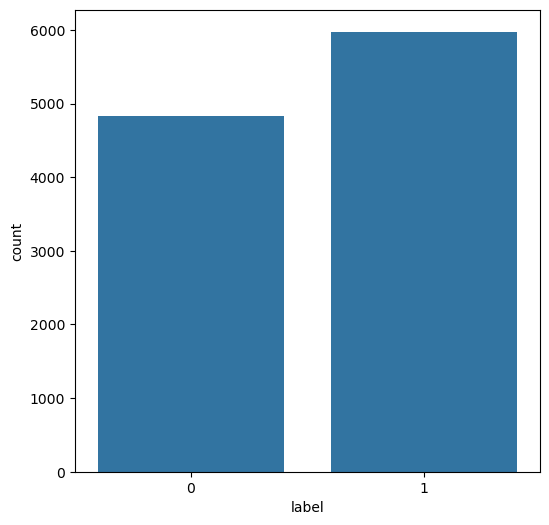

In [13]:
plt.figure(figsize=(6,6))
sns.countplot(x="label",data=data)

In [14]:
data['word_count'] = data['msg'].apply(lambda x: len(x.split()))

In [15]:
data

,label,msg,word_count
0,0,"Go until jurong point, crazy.. Available only ...",20
1,0,Ok lar... Joking wif u oni...,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,0,U dun say so early hor... U c already then say...,11
4,0,"Nah I don't think he goes to usf, he lives aro...",13
...,...,...,...
10796,1,Want explicit SEX in 30 secs? Ring 02073162414...,16
10797,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33
10798,1,Had your contract mobile 11 Mnths? Latest Moto...,28
10799,1,REMINDER FROM O2: To get 2.50 pounds free call...,28


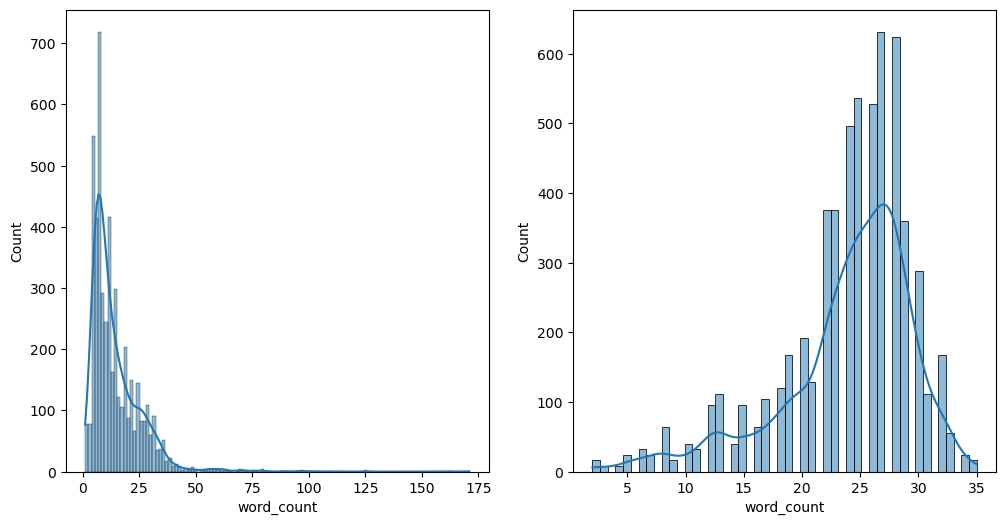

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(data[data['label'] == 0]['word_count'], kde=True)

plt.subplot(1,2,2)
sns.histplot(data[data['label'] == 1]['word_count'], kde=True)

plt.show()

In [33]:
def currency(text):
    curr_sym = ['€', '$', '¥', '£', '₹']
    for i in curr_sym:
        if i in text:
            return 1
    return 0

data['curr_sym'] = data['msg'].apply(currency)

data

,label,msg,word_count,curr_sym,cur_sym
0,0,"Go until jurong point, crazy.. Available only ...",20,0,0
1,0,Ok lar... Joking wif u oni...,6,0,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0,0
3,0,U dun say so early hor... U c already then say...,11,0,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0,0
...,...,...,...,...,...
10796,1,Want explicit SEX in 30 secs? Ring 02073162414...,16,0,0
10797,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33,1,1
10798,1,Had your contract mobile 11 Mnths? Latest Moto...,28,0,0
10799,1,REMINDER FROM O2: To get 2.50 pounds free call...,28,0,0


In [35]:
data['cur_sym'] = data['msg'].apply(currency)

In [36]:
data

,label,msg,word_count,curr_sym,cur_sym
0,0,"Go until jurong point, crazy.. Available only ...",20,0,0
1,0,Ok lar... Joking wif u oni...,6,0,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0,0
3,0,U dun say so early hor... U c already then say...,11,0,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0,0
...,...,...,...,...,...
10796,1,Want explicit SEX in 30 secs? Ring 02073162414...,16,0,0
10797,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33,1,1
10798,1,Had your contract mobile 11 Mnths? Latest Moto...,28,0,0
10799,1,REMINDER FROM O2: To get 2.50 pounds free call...,28,0,0


<Axes: xlabel='cur_sym', ylabel='count'>

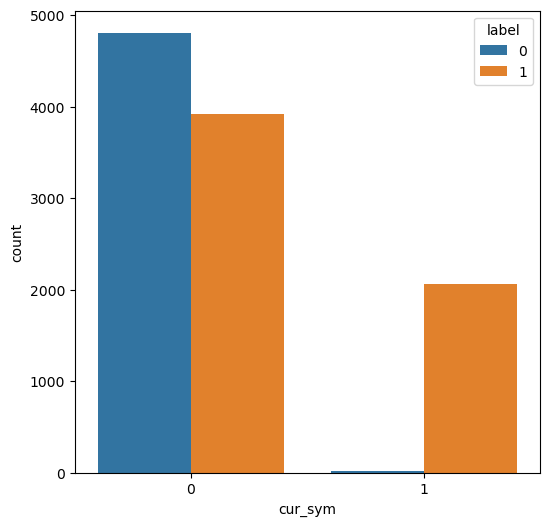

In [37]:
plt.figure(figsize=(6,6))
sns.countplot(x="cur_sym",data=data, hue='label')

In [38]:
def num(text):
    for i in text:
        if ord(i) >= 48 and ord(i) <= 57:
            return 1
    return 0

In [39]:
data['has_num'] = data['msg'].apply(num)

In [40]:
data

,label,msg,word_count,curr_sym,cur_sym,has_num
0,0,"Go until jurong point, crazy.. Available only ...",20,0,0,0
1,0,Ok lar... Joking wif u oni...,6,0,0,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,0,0,1
3,0,U dun say so early hor... U c already then say...,11,0,0,0
4,0,"Nah I don't think he goes to usf, he lives aro...",13,0,0,0
...,...,...,...,...,...,...
10796,1,Want explicit SEX in 30 secs? Ring 02073162414...,16,0,0,1
10797,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,33,1,1,1
10798,1,Had your contract mobile 11 Mnths? Latest Moto...,28,0,0,1
10799,1,REMINDER FROM O2: To get 2.50 pounds free call...,28,0,0,1


<Axes: xlabel='has_num', ylabel='count'>

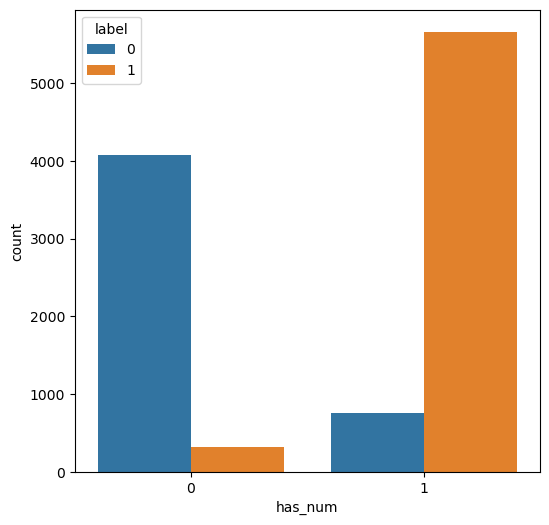

In [41]:
plt.figure(figsize=(6,6))
sns.countplot(x="has_num",data=data, hue='label')

In [42]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [43]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\telso\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [46]:
corpus = []
wnl = WordNetLemmatizer()

for sms in list(data.msg):
    msg = re.sub(pattern='[^a-zA-Z]', repl=' ', string=sms)
    msg = msg.lower()
    msg = [word for word in msg.split() if word not in set(stopwords.words('english'))]
    msg = [wnl.lemmatize(word) for word in msg]
    msg = ' '.join(msg)
    corpus.append(msg)

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)
vectors = tfidf.fit_transform(corpus).toarray()
features = tfidf.get_feature_names_out()

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [73]:
X = pd.DataFrame(vectors, columns=features)
X['word_count']= data['word_count'].values
X['has_num']= data['has_num'].values
X['cur_sym']= data['cur_sym'].values
y = data['label']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [75]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [76]:
model1 = SVC()
model1.fit(X_train, y_train)
y_pred = model1.predict(X_test)
print(classification_report(y_test, y_pred))

model2 = LogisticRegression()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.92      0.87      0.89       931
           1       0.90      0.94      0.92      1230

    accuracy                           0.91      2161
   macro avg       0.91      0.91      0.91      2161
weighted avg       0.91      0.91      0.91      2161

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       931
           1       0.98      0.98      0.98      1230

    accuracy                           0.97      2161
   macro avg       0.97      0.97      0.97      2161
weighted avg       0.97      0.97      0.97      2161



C:\Users\telso\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [77]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred3 = mnb.predict(X_test)
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       931
           1       0.94      0.95      0.95      1230

    accuracy                           0.94      2161
   macro avg       0.94      0.94      0.94      2161
weighted avg       0.94      0.94      0.94      2161



<Axes: >

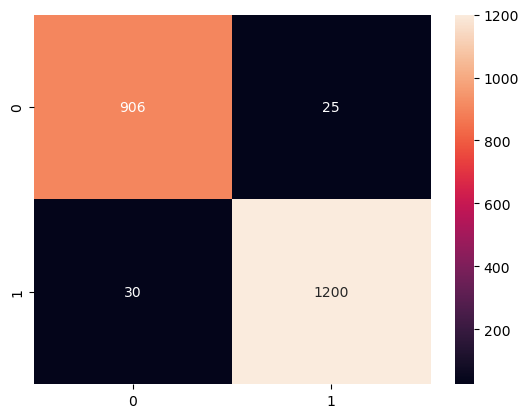

In [78]:
cm=confusion_matrix(y_test, y_pred2)
sns.heatmap(cm , annot=True , fmt='d')